## Breast Cancer Ultrasound Image Classification Using CNN with TensorFlow

### Project Introduction

This project focuses on building a deep learning model to classify breast ultrasound images using a Convolutional Neural Network (CNN). The goal is to automatically distinguish between benign and malignant cases based on image patterns. Using the BreastMNIST dataset and the TensorFlow/Keras framework, the project demonstrates the complete machine learning pipeline, including data loading, preprocessing, model development, training, evaluation, and prediction. 

This project highlights practical skills in medical image analysis, deep learning (CNN) and model evaluation, and serves as a portfolio example of applying artificial intelligence in healthcare.

### Importing Required Libraries

This cell imports all the necessary libraries and modules used in the project.  
- `medmnist` and `BreastMNIST` are used to load the BreastMNIST medical image dataset.  
- `numpy` is used for numerical operations and handling arrays.  
- `tensorflow` and `keras` are used to build and train the Convolutional Neural Network (CNN) model.  
- `to_categorical` is used to convert class labels into one-hot encoded format.  
- `train_test_split` is used to divide the dataset into training and validation sets.

In [2]:
import medmnist
from medmnist import INFO, BreastMNIST
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

### Dataset Configuration

Basic information about the dataset is set up. 

- `data_flag` specifies the dataset name (`breastmnist`).  
- `INFO[data_flag]` retrieves metadata about the dataset.  
- `task` stores the type of machine learning task (classification).  
- `n_channels` stores the number of image channels (e.g., grayscale).  
- `n_classes` stores the number of target classes, which are benign and malignant (2 classes).


In [3]:
# 1. Dataset Setup
# ------------------------
data_flag = 'breastmnist'
info = INFO[data_flag]
task = info['task']  # classification
n_channels = info['n_channels']
n_classes = len(info['label'])  # 2 classes (benign/malignant)

### Downloading the Dataset

The BreastMNIST dataset is downloaded and loaded. 

- `train_dataset` loads the training data split.  
- `test_dataset` loads the test data split.  
- `download=True` automatically downloads the dataset if it is not already available locally.

In [19]:
# Download dataset
train_dataset = BreastMNIST(split='train', download=True)
test_dataset = BreastMNIST(split='test', download=True)

### Visualizing a Sample Image

An example image from the dataset is displayed.

- `matplotlib.pyplot` is imported for visualization.  
- An image and its label are retrieved from the training dataset.  
- `plt.imshow()` displays the image.  
- `plt.title()` adds a title to the plot.

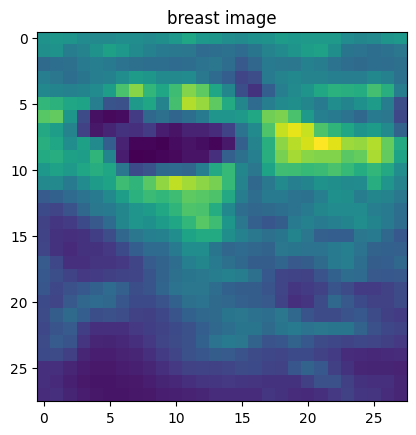

In [20]:
import matplotlib.pyplot as plt
# Get image and label
img, label = train_dataset[1]
plt.imshow(img)
plt.title('breast image')
plt.show()

### Converting the Dataset to NumPy Arrays

The dataset objects is converted into NumPy arrays for easier processing.

- `X_train` stores all training images as a NumPy array.  
- `y_train` stores the corresponding training labels.  
- `X_test` stores all test images as a NumPy array.  
- `y_test` stores the corresponding test labels.

This step prepares the data for preprocessing and model training.

In [21]:
# Convert dataset to numpy arrays
X_train = np.array([img[0] for img in train_dataset])
y_train = np.array([label for _, label in train_dataset])

X_test = np.array([img[0] for img in test_dataset])
y_test = np.array([label for _, label in test_dataset])

In [22]:
#check the shape of training features
X_train.shape

(546, 28, 28)

In [23]:
#check the shape of training labels
y_train.shape

(546, 1)

In [24]:
#check the shape of testing features
X_test.shape

(156, 28, 28)

In [25]:
##check the shape of testing labels
y_test.shape

(156, 1)

### Normalizing Image Pixel Values

This cell scales the image pixel values to a range between 0 and 1.

- Dividing by `255.0` converts raw pixel values (0–255) into normalized floating-point values between 0 and 1.  
- Normalization helps the neural network train faster and perform more stably.

In [26]:
# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

### One-Hot Encoding the Labels

The class labels are converted into one-hot encoded vectors.

- `to_categorical()` transforms numeric class labels into binary vectors.  
- This format is required when using the `categorical_crossentropy` loss function in neural networks.  
- It allows the model to handle multi-class classification tasks more effectively.

In [28]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train, n_classes)
y_test = to_categorical(y_test, n_classes)

In [29]:
#check the shape of labels after one-hot encoding
y_train.shape

(546, 2)

### Creating a Validation Dataset

The part of the training data is split into into a separate validation set. The validation set is used to monitor the model’s performance during training and to detect overfitting without using the test data.

- `train_test_split()` divides the data so that 90% is used for training and 10% is used for validation.  
- `random_state=42` ensures the split is reproducible.  
- The `print()` statement displays the shapes of the training, validation, and test datasets to verify the data sizes.

In [30]:
# Create validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (491, 28, 28), Validation shape: (55, 28, 28), Test shape: (156, 28, 28)


### Building the CNN Model

The Convolutional Neural Network (CNN) model is defined and compiled. 

- `Sequential()` creates a linear stack of layers.  
- `Conv2D` layers extract spatial features from the images using filters and ReLU activation.  
- `MaxPooling2D` layers reduce the spatial dimensions and help control overfitting.  
- `Flatten()` converts the 2D feature maps into a 1D vector.  
- `Dense` layers learn high-level patterns.  
- `Dropout(0.5)` randomly disables neurons during training to reduce overfitting.  
- The final `Dense` layer uses `softmax` to output class probabilities.

The model is compiled using:
- The `Adam` optimizer,  
- `categorical_crossentropy` loss function, and  
- `accuracy` as the performance metric.

`model.summary()` displays the architecture of the model.

In [33]:
# Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], n_channels)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 240,514 (939.51 KB)

 Trainable params: 240,514 (939.51 KB)

 Non-trainable params: 0 (0.00 B)

### Custom Early Stopping Callback

A custom early stopping callback is defined to control the training process.

- A new callback class `EarlyStopAtAcc` is created by inheriting from `tf.keras.callbacks.Callback`.  
- The `threshold` parameter sets the target validation accuracy (default is 0.9).  
- `on_epoch_end()` checks the validation accuracy after each epoch.  
- If the validation accuracy reaches or exceeds the threshold, training is stopped early to save time and prevent overfitting.

In [34]:
class EarlyStopAtAcc(tf.keras.callbacks.Callback):
    def __init__(self, threshold=0.9):
        super(EarlyStopAtAcc, self).__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get("val_accuracy")
        if acc is not None and acc >= self.threshold:
            print(f"\nReached val_accuracy {acc:.2f} ≥ {self.threshold}. Stopping training!")
            self.model.stop_training = True

### Training the Model
Now, the CNN model is trained using the prepared training data.

- `EarlyStopAtAcc` is initialized to stop training when validation accuracy reaches 90%.  
- `model.fit()` starts the training process.  
- The model is trained for up to `30` epochs with a batch size of `32`.  
- Validation data is provided to monitor performance during training.  
- The custom early stopping callback is used to automatically stop training when the target accuracy is achieved.  

The training history (loss and accuracy per epoch) is stored in the `history` object.

In [35]:
# 3. Train the Model
# ------------------------
earlystop = EarlyStopAtAcc(threshold=0.90)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[earlystop]
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.6884 - loss: 0.5938 - val_accuracy: 0.8000 - val_loss: 0.4938
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7230 - loss: 0.5579 - val_accuracy: 0.8000 - val_loss: 0.4657
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7251 - loss: 0.5370 - val_accuracy: 0.8000 - val_loss: 0.4714
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7291 - loss: 0.5184 - val_accuracy: 0.7818 - val_loss: 0.5385
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7678 - loss: 0.5059 - val_accuracy: 0.8182 - val_loss: 0.4859
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7719 - loss: 0.4919 - val_accuracy: 0.8364 - val_loss: 0.4085
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7678 - loss: 0.4867 - val_accuracy: 0.8364 - val_loss: 0.4116
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8004 - loss: 0.4472 - val_accuracy: 0.8727 - v

### Evaluating the Model

The trained model is evaluated using the test dataset.

- `model.evaluate()` calculates the loss and accuracy on unseen test data.  
- `test_loss` stores the test loss value.  
- `test_acc` stores the test accuracy value.  
- The `print()` statement displays the final test accuracy as a percentage.

This step measures how well the model generalizes to new, unseen data.

In [36]:
# Evaluate Model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8141 - loss: 0.3772
Test Accuracy: 81.41%


### Validation vs Test Accuracy

The training process was stopped early when the validation accuracy reached **90%** to prevent overfitting and save training time. However, the final **test accuracy (81.41%)** is lower than the validation accuracy because the test set contains completely unseen data that may be more challenging or slightly different in distribution.

This difference is expected in real-world machine learning projects. It can indicate that the model generalizes reasonably well, but there is still need for improvement through techniques such as more training data (current training data has just around 500 images), data augmentation, or further model tuning.

### Saving the Trained Model

This cell saves the trained CNN model to a file for future use.

- `model.save("breastmnist_cnn_model.h5")` stores the entire model, including architecture, weights, and training configuration.  
- The saved model can be reloaded later without retraining.

Saving the model allows it to be reused for deployment or further testing.

In [37]:
# Save the trained model
model.save("breastmnist_cnn_model.h5")
print("Model saved successfully!")

Model saved successfully!


### Making a Prediction on a Sample Image

The trained model is usedto make a prediction on a single image.

- An example image and its true label are selected from the training dataset.  
- The image is converted to a NumPy array and reshaped to match the model’s input format.  
- `model.predict()` generates the probability scores for each class.  
- `np.argmax()` converts the predicted probabilities into a class label.  
- The image is displayed with its true label and predicted label for comparison.

This step shows how the trained model can be used for real-time predictions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


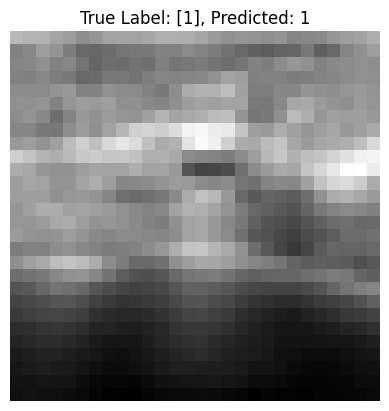

In [38]:
# Pick an image from the dataset
# Example: pick the 5th image
img, true_label = train_dataset[3]
img = np.array(img)
# If the image has a channel dimension, keep it for prediction
img_input = img[np.newaxis, ...]  # shape: (1, 28, 28, 1)

# Predict
prediction = model.predict(img_input)
pred_label = np.argmax(prediction, axis=1)[0]  # for softmax 2-neuron output

# Show the image and compare
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"True Label: {true_label}, Predicted: {pred_label}")
plt.axis('off')
plt.show()

### Comment on Prediction Result
In this example, both the **true label** and the **predicted label** are `1`, which means the model correctly classified the image.  
Here, the value `1` represents the positive class in the dataset (commonly mapped to the malignant class), while `0` represents the negative class (commonly mapped to the benign class).

This shows that the model can successfully make correct predictions on sample images. 

### Conclusion and Future Work

This project successfully implemented a Convolutional Neural Network (CNN) to classify breast ultrasound images into benign and malignant categories. The model demonstrated good performance, achieving strong validation accuracy and reasonable generalization on unseen test data.

For future improvements, the model could benefit from techniques such as training data collection, data augmentation, hyperparameter tuning, deeper network architectures, and cross-validation. These steps could further improve robustness and real-world performance.